# Movie Industry Analysis for New Studio Strategy

## Business Problem

Your company is entering the movie production industry but lacks experience in creating films. To reduce risk and maximize profitability, the company needs data-driven insights into what types of movies perform best at the box office.

This project analyzes movie data from IMDB and Box Office Mojo to identify patterns between movie characteristics (such as genre, ratings, and studio) and financial performance.

The goal is to provide actionable recommendations on what types of films the new studio should produce.

---

## Table of Contents
1. Data Overview and Understanding
2. Data Extraction and Loading
3. Data Exploration
4. Data Cleaning and Preparation
5. Data Merging
6. Exploratory Data Analysis (EDA)
7. Business Recommendations
8. Conclusion

---

## 1. Data Overview and Understanding

This analysis combines data from two primary sources: 
1. IMDB
2. Box Office Mojo.

The IMDB dataset contains descriptive attributes of movies, including their titles, genres, runtime, and audience ratings. These variables help us understand the characteristics of each film.

The Box Office Mojo dataset provides financial performance data, specifically domestic and foreign gross revenue. This allows us to measure how successful each movie was in the market.

By merging these datasets, we can examine how specific movie characteristics relate to financial outcomes hence influencing box office success.

---


## 2. Data Extraction and Loading

The IMDB data is stored in a SQLite database, which requires querying using SQL. This allows us to selectively extract only the relevant tables needed for analysis, improving efficiency.

The Box Office Mojo data is provided as a compressed CSV file, which can be loaded directly into pandas.


1. Importing Libraries:

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import zipfile

2. Extracting the IMDB Database:

In [8]:
with zipfile.ZipFile('zippedData/im.db.zip', 'r') as z:
    z.extractall('zippedData/')

3. Connecting to the IMDB Database:

In [9]:
con = sqlite3.connect('zippedData/im.db')
cur = con.cursor()

4. Loading the Box Office Mojo Dataset:

In [10]:
bom = pd.read_csv('zippedData/bom.movie_gross.csv.gz', compression='gzip')
bom

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


---

## 3. Data Exploration

We explore the structure of the IMDB database and extract relevant tables using SQL queries.

We then perform exploratory queries on key tables to understand their contents and structure. Some tables are also loaded directly into pandas DataFrames to make them easier to work with.

Finally, we combine relevant tables using SQL joins to create a unified dataset that links movie attributes such as titles and genres with performance metrics like ratings and number of votes.

1. Creating a Database Cursor:

In [11]:
cur=con.cursor()

2. Retrieving all Table Names in the Database:

In [12]:
cur.execute("SELECT name FROM sqlite_master WHERE type='table'");
print(cur.fetchall())


[('movie_basics',), ('directors',), ('known_for',), ('movie_akas',), ('movie_ratings',), ('persons',), ('principals',), ('writers',)]


3. Querying all records from the movie_akas Table using SQL :

In [13]:
cur.execute("SELECT * FROM movie_akas");
cur.fetchall()

[('tt0369610', 10, 'Джурасик свят', 'BG', 'bg', None, None, 0.0),
 ('tt0369610', 11, 'Jurashikku warudo', 'JP', None, 'imdbDisplay', None, 0.0),
 ('tt0369610',
  12,
  'Jurassic World: O Mundo dos Dinossauros',
  'BR',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610',
  13,
  'O Mundo dos Dinossauros',
  'BR',
  None,
  None,
  'short title',
  0.0),
 ('tt0369610', 14, 'Jurassic World', 'FR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 15, 'Jurassic World', 'GR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 16, 'Jurassic World', 'IT', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 17, 'Jurski svijet', 'HR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 18, "Olam ha'Yura", 'IL', 'he', 'imdbDisplay', None, 0.0),
 ('tt0369610',
  19,
  'Jurassic World: Mundo Jurásico',
  'MX',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610',
  1,
  'Jurassic World: Sauruste maailm',
  'EE',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610', 20, 'Jurassic World', 'SE', None, 'im

4. Loading the movie_ratings Table into a DataFrame:

In [14]:
df_ratings=pd.read_sql_query('''SELECT * FROM movie_ratings''',con)
print(df_ratings)

         movie_id  averagerating  numvotes
0      tt10356526            8.3        31
1      tt10384606            8.9       559
2       tt1042974            6.4        20
3       tt1043726            4.2     50352
4       tt1060240            6.5        21
...           ...            ...       ...
73851   tt9805820            8.1        25
73852   tt9844256            7.5        24
73853   tt9851050            4.7        14
73854   tt9886934            7.0         5
73855   tt9894098            6.3       128

[73856 rows x 3 columns]


5. Loading the movie_akas Table into a DataFrame:

In [15]:
df_aka=pd.read_sql_query('''SELECT * FROM movie_akas''',con)
print(df_aka)

         movie_id  ordering                                    title region  \
0       tt0369610        10                            Джурасик свят     BG   
1       tt0369610        11                        Jurashikku warudo     JP   
2       tt0369610        12  Jurassic World: O Mundo dos Dinossauros     BR   
3       tt0369610        13                  O Mundo dos Dinossauros     BR   
4       tt0369610        14                           Jurassic World     FR   
...           ...       ...                                      ...    ...   
331698  tt9827784         2                       Sayonara kuchibiru   None   
331699  tt9827784         3                            Farewell Song    XWW   
331700  tt9880178         1                              La atención   None   
331701  tt9880178         2                              La atención     ES   
331702  tt9880178         3                            The Attention    XWW   

       language        types   attributes  is_origi

6. Joining Movie Basics and Ratings Tables:

In [16]:
query = '''
SELECT mb.primary_title, mb.genres, mr.averagerating, mr.numvotes
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mr.numvotes >= 1000
ORDER BY mr.averagerating DESC
'''

df = pd.read_sql(query, con)
df

,primary_title,genres,averagerating,numvotes
0,Once Upon a Time ... in Hollywood,"Comedy,Drama",9.7,5600
1,Ekvtime: Man of God,"Biography,Drama,History",9.6,2604
2,I Want to Live,"Adventure,Biography,Documentary",9.6,1339
3,Aloko Udapadi,"Drama,History",9.5,6509
4,Peranbu,Drama,9.4,9629
...,...,...,...,...
9612,Smolensk,"Drama,Thriller",1.4,7383
9613,Amazing China,Documentary,1.3,3244
9614,Potato Salad,"Comedy,Horror",1.3,6249
9615,Cumali Ceber: Allah Seni Alsin,Comedy,1.3,36986


---

## 4. Data Cleaning and Preparation 

In this section, we clean and prepare both the IMDB and Box Office Mojo datasets to ensure they are suitable for analysis.

For the IMDB dataset, the cleaning process focuses on handling missing values, filtering out incomplete records, and refining the dataset to include only relevant movies with sufficient data for analysis. Additional processing is done to create structured analytical datasets using SQL joins.

For the Box Office Mojo dataset, cleaning involves handling missing values and ensuring that financial data such as gross revenue is in a consistent format suitable for numerical analysis.

### SECTION 1: IMDB Data

1. Checking for Missing Values in the Dataset:

In [17]:
print(df.isnull().sum())

primary_title    0
genres           2
averagerating    0
numvotes         0
dtype: int64


2. Removing Rows with Missing Genre Information:

In [34]:
df = df.dropna(subset=['genres'])
print(df.shape)

(9615, 4)


3. Recreating the Dataset from SQL Query :

In [35]:
df = pd.read_sql(query, con) # Resets the df to its original state
df

,primary_title,genres,averagerating,numvotes
0,Once Upon a Time ... in Hollywood,"Comedy,Drama",9.7,5600
1,Ekvtime: Man of God,"Biography,Drama,History",9.6,2604
2,I Want to Live,"Adventure,Biography,Documentary",9.6,1339
3,Aloko Udapadi,"Drama,History",9.5,6509
4,Peranbu,Drama,9.4,9629
...,...,...,...,...
9612,Smolensk,"Drama,Thriller",1.4,7383
9613,Amazing China,Documentary,1.3,3244
9614,Potato Salad,"Comedy,Horror",1.3,6249
9615,Cumali Ceber: Allah Seni Alsin,Comedy,1.3,36986


4. Creating SQL Query to Retrieve Writers and Movie Performance Data :

In [20]:
query_writers = '''
SELECT p.primary_name, mb.primary_title, mr.averagerating, mr.numvotes
FROM writers w
JOIN persons p ON w.person_id = p.person_id
JOIN movie_basics mb ON w.movie_id = mb.movie_id
JOIN movie_ratings mr ON w.movie_id = mr.movie_id
WHERE mr.numvotes >= 1000
ORDER BY mr.averagerating DESC
LIMIT 20
'''

# Loading the writers data into a DataFrame
df_writers = pd.read_sql(query_writers, con)
df_writers

,primary_name,primary_title,averagerating,numvotes
0,Quentin Tarantino,Once Upon a Time ... in Hollywood,9.7,5600
1,Nikoloz Khomasuridze,Ekvtime: Man of God,9.6,2604
2,Lasha Kankava,Ekvtime: Man of God,9.6,2604
3,Karzan Kardozi,I Want to Live,9.6,1339
4,Saman Weeraman,Aloko Udapadi,9.5,6509
5,Saman Weeraman,Aloko Udapadi,9.5,6509
6,Ram,Peranbu,9.4,9629
7,Ram,Peranbu,9.4,9629
8,Ram,Peranbu,9.4,9629
9,Anjana Krishnakumar,Peranbu,9.4,9629


---

### SECTION 2: BOM Data

1. Checking for Missing Values in the Dataset :

In [21]:
print(bom.isnull().sum())

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64


2. Converting Domestic Gross and Foreign Gross to Numeric Format :

In [22]:
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')
bom['domestic_gross'] = pd.to_numeric(bom['domestic_gross'], errors='coerce')

3. Handling Missing Values in Foreign Gross:

Since 'foreign_gross' has a lot of missing values, we can fill those with 0, assuming that if it's missing, it means the movie didn't earn any foreign gross.


In [23]:
bom['foreign_gross'] = bom['foreign_gross'].fillna(0)

4. Removing Rows with Missing Domestic Gross Values :

In [24]:
bom = bom.dropna(subset=['domestic_gross'])

5. Fill categorical missing values :

In [36]:
bom.loc[:, 'studio'] = bom['studio'].fillna('Unknown')

6. Creating Total Gross Revenue Feature :

In [37]:
# Add a new column for total gross
bom.loc[:, 'total_gross'] = bom['domestic_gross'] + bom['foreign_gross']

7. Verifing that the data is cleaned:

In [27]:
print(bom.isnull().sum())
print(bom.shape)

title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
total_gross       0
dtype: int64
(3359, 6)


---

## 5. Data Merging

To analyze the relationship between movie characteristics and financial performance, the IMDB and Box Office Mojo datasets must be combined into a single dataset.

The datasets are merged using the movie title as the common key. After merging, we perform initial exploratory aggregation to understand how different movie genres perform in terms of average gross revenue. This helps identify which types of movies generate the highest financial returns.

1. Merging IMDB and BOM Datasets on Movie Title :

In [28]:
df_merged = pd.merge(df, bom, left_on='primary_title', right_on='title', how='inner')
print(df_merged.shape)
df_merged.head()

(2447, 10)


,primary_title,genres,averagerating,numvotes,title,studio,domestic_gross,foreign_gross,year,total_gross
0,Burn the Stage: The Movie,"Documentary,Music",8.8,2067,Burn the Stage: The Movie,Trafalgar,4200000.0,16100000.0,2018,20300000.0
1,Inception,"Action,Adventure,Sci-Fi",8.8,1841066,Inception,WB,292600000.0,535700000.0,2010,828300000.0
2,Coriolanus,"Drama,History,War",8.7,1347,Coriolanus,Wein.,757000.0,315000.0,2012,1072000.0
3,Interstellar,"Adventure,Drama,Sci-Fi",8.6,1299334,Interstellar,Par.,188000000.0,489400000.0,2014,677400000.0
4,Senna,"Biography,Documentary,Sport",8.6,55318,Senna,PDA,1600000.0,6600000.0,2011,8200000.0


2. Calculating Average Gross Revenue by Genre :

In [38]:
genre_gross = df_merged.groupby('genres')['total_gross'].mean().sort_values(ascending=False).head(10)
# Display the top 10 genres by average total gross
print(genre_gross)

genres
Adventure,Drama,Sport        1.276400e+09
Adventure,Fantasy            7.040333e+08
Adventure,Drama,Sci-Fi       6.537500e+08
Action,Adventure,Sci-Fi      5.880021e+08
Action,Comedy,Mystery        5.441000e+08
Action,Adventure,Fantasy     4.399933e+08
Biography,Drama,Musical      4.350000e+08
Adventure,Mystery,Sci-Fi     4.034000e+08
Action,Adventure,Thriller    3.882411e+08
Adventure,Family,Fantasy     3.849875e+08
Name: total_gross, dtype: float64


---

## 6. Exploratory Data Analysis (EDA)

In this section, we explore the relationships between movie characteristics and financial performance using visual analysis.

After merging the IMDB and Box Office Mojo datasets, we use exploratory data analysis techniques to identify patterns and trends in the data. Visualizations are created to understand how different features such as genre, ratings, and studio influence total box office revenue.

### Visualization 1: Average Total Gross Revenue by Genre:

This visualization explores how different movie genres perform in terms of average box office revenue.

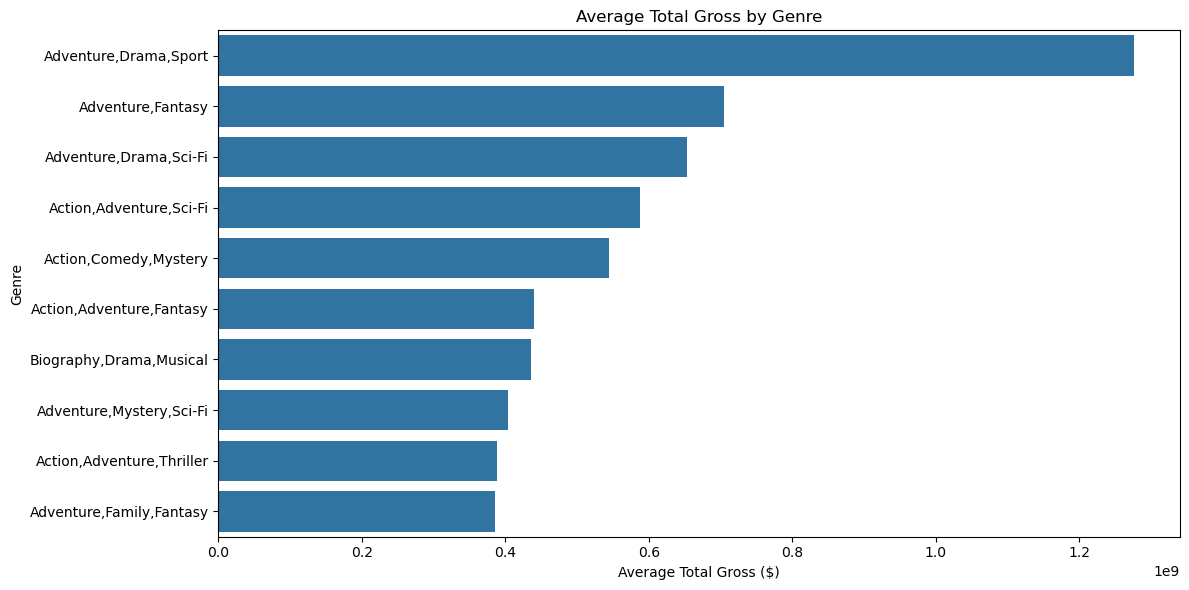

In [30]:
plt.figure(figsize=(12,6))
sns.barplot(x=genre_gross.values, y=genre_gross.index)
plt.title('Average Total Gross by Genre')
plt.xlabel('Average Total Gross ($)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### Visualization 2: Relationship Between Movie Rating and Total Gross:

This visualization examines whether there is a relationship between a movie’s average rating and its total box office revenue.

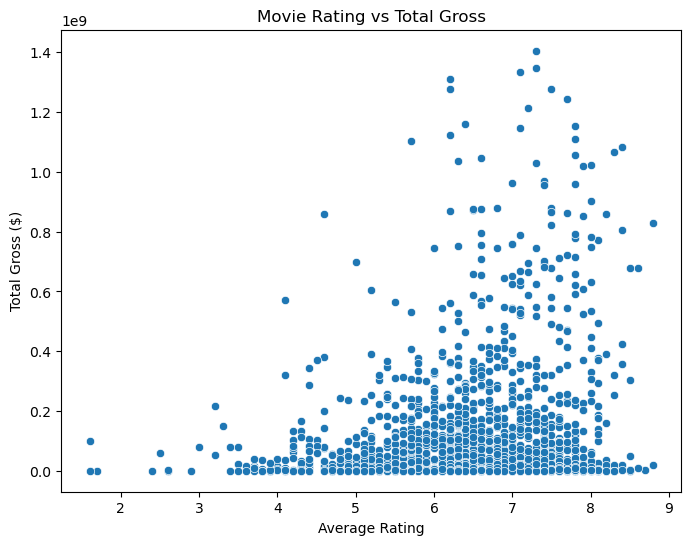

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_merged, x='averagerating', y='total_gross')
plt.title('Movie Rating vs Total Gross')
plt.xlabel('Average Rating')
plt.ylabel('Total Gross ($)')
plt.show()

### Visualization 3: Average Total Gross Revenue by Studio:

This analysis evaluates how different film studios perform in terms of average box office revenue.

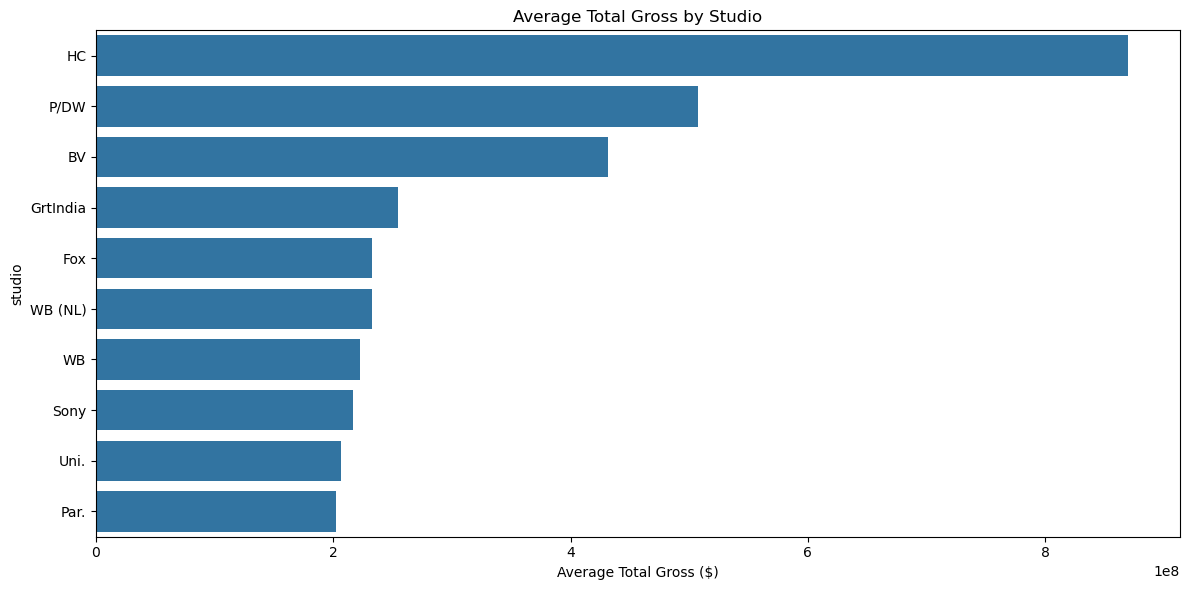

In [32]:
studio_gross = df_merged.groupby('studio')['total_gross'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=studio_gross.values, y=studio_gross.index)
plt.title('Average Total Gross by Studio')
plt.xlabel('Average Total Gross ($)')
plt.tight_layout()
plt.show()

--- 

## 7. Business Recommendations :

### Key Findings:
From the analysis performed in the previous sections, several important patterns were observed:

1. Certain genres consistently generate higher average box office revenue compared to others.

2. There is a positive relationship between movie ratings and total gross, although it is not perfectly linear.

3. Some studios outperform others in terms of average revenue, indicating differences in production success and market reach.




### 1: Prioritize High-Gross Genres Identified in the Dataset

Visualization 1 analysis shows that some genres consistently generate higher average total gross revenue than others. For example, the top genres in your genre_gross.head(10) output clearly outperform lower-ranked genres in terms of box office returns.

#### Recommendation 1:
The studio should prioritize investing in the top-performing genres identified in your dataset (as shown in our genre_gross.head(10) output). These genres have historically generated higher returns and are more likely to maximize profitability for new productions.

### 2: Focus on Improving Film Quality to Strengthen Ratings and Revenue Potential

Visualization 2 analysis shows a positive but weak relationship between ratings and revenue.
This means that while higher-rated movies tend to earn more, ratings alone are not enough to guarantee success.

#### Recommendation 2:
The studio should invest in improving film quality (storytelling, acting, production value) to increase ratings, while also ensuring strong market appeal to maximize revenue potential.



### 3: Benchmark and Learn from High-Performing Studios

Visualization 3 analysis revealed that a small group of studios consistently achieve much higher average total gross revenue than others.
These studios represent proven success patterns in production and distribution.

#### Recommendation 3:
The new studio should benchmark against the top-performing studios in our dataset and analyze their strategies, especially in terms of genre selection and production scale.


---

## 8. Conclusion

The goal of this project was to analyze movie industry data in order to provide actionable insights for a new movie studio entering the market. By combining IMDb datasets (including movie basics, ratings, and crew information) with Box Office Mojo revenue data, the analysis aimed to understand the key factors that influence a movie’s financial success.

The study focused on three main areas: genre performance, audience ratings, and studio performance. Through data cleaning, merging, and exploratory data analysis, we investigated how these factors relate to total box office gross.

The analysis revealed that certain movie genres consistently generate higher average revenue, making genre selection a critical factor for success. Additionally, while there is a positive relationship between movie ratings and box office performance, it is not strictly linear, indicating that high ratings alone do not guarantee commercial success. Studio-level analysis further showed significant variation in performance, with some studios achieving consistently higher average gross revenue than others.

Based on these findings, the project provides clear recommendations for the new studio, including focusing on high-performing genres, improving production quality to support higher ratings, and benchmarking against successful studios in the industry.

Overall, this project demonstrates that data-driven decision-making can significantly reduce risk and improve strategic planning in the film industry by aligning creative production choices with proven market performance trends.